# Model Evaluation

This notebook evaluates the performance of the trained Random Forest Regression model for predicting order values.

The evaluation includes:

- Loading the saved model
- Preparing the dataset
- Making predictions
- Performance metrics
- Actual vs Predicted comparison
- Residual analysis
- Feature importance
- Business insights

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

In [3]:
df = pd.read_csv("../data/processed/engineered_data.csv")

df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,late_delivery,total_order_value,high_value_order,revenue_bucket,order_value,customer_order_count,repeat_customer,customer_total_spending,average_order_value_per_customer,installment_category
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,False,38.71,False,Medium,116.13,2,True,392.50,196.25,Single Payment
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,False,38.71,False,Medium,116.13,2,True,392.50,196.25,Single Payment
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,False,38.71,False,Medium,116.13,2,True,392.50,196.25,Single Payment
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,False,141.46,False,Medium,141.46,1,False,141.46,141.46,Single Payment
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,False,179.12,False,High,179.12,1,False,179.12,179.12,Short Installment


In [4]:
'''
## Load Saved Model

Load the trained Random Forest model saved during the Machine Learning phase.
'''

model = joblib.load("../models/random_forest_model.pkl")

print("Model Loaded Successfully!")

Model Loaded Successfully!


In [5]:
y = df["order_value"]

drop_columns = [
    'order_id',
    'customer_id',
    'customer_unique_id',
    'product_id',
    'seller_id',
    'review_id',
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'shipping_limit_date',
    'review_creation_date',
    'review_answer_timestamp',
    'review_comment_title',
    'review_comment_message',
    'price',
    'freight_value',
    'total_order_value',
    'payment_value',
    'high_value_order',
    'revenue_bucket',
    'customer_total_spending',
    'average_order_value_per_customer',
    'order_value'
]

X = df.drop(columns=drop_columns)

In [6]:
categorical_columns = X.select_dtypes(include=["object", "bool"]).columns

label_encoder = LabelEncoder()

for column in categorical_columns:
    X[column] = label_encoder.fit_transform(
        X[column].astype(str)
    )

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [8]:
predictions = model.predict(X_test)

## Performance Metrics

The model is evaluated using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

In [10]:
mae = mean_absolute_error(y_test, predictions)

rmse = np.sqrt(mean_squared_error(y_test, predictions))

r2 = r2_score(y_test, predictions)

print("MAE :", round(mae,2))
print("RMSE:", round(rmse,2))
print("R² :", round(r2,4))

MAE : 87.62
RMSE: 224.67
R² : 0.754


# Actual vs Predicted Values

The table below compares the actual order values with the values predicted by the Random Forest model.

In [12]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": predictions
})

comparison.head(20)

,Actual,Predicted
0,63.49,196.3577
1,305.90,111.5886
2,80.19,100.7758
3,208.20,97.3100
4,352.16,269.1911
5,106.87,116.2607
6,87.85,101.0733
7,59.60,80.1884
8,64.09,75.3460
9,263.84,222.9220


# Actual vs Predicted Scatter Plot

This visualization compares the predicted values with the actual values. A good regression model produces points that lie close to the diagonal line.

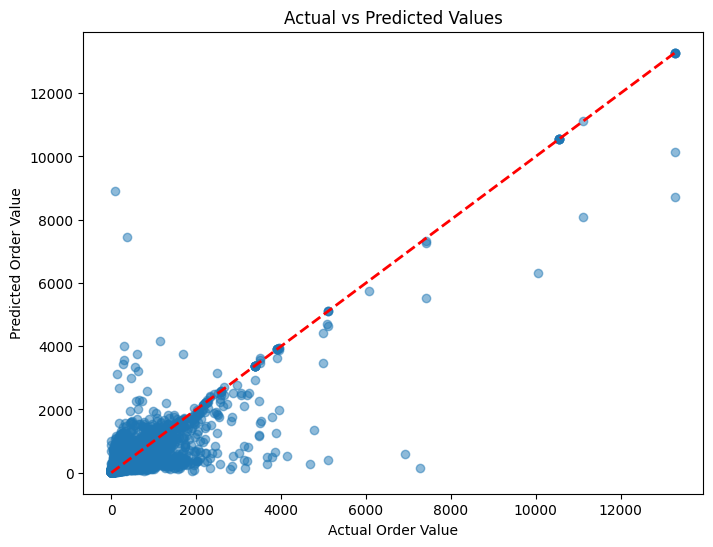

In [14]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, predictions, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

plt.xlabel("Actual Order Value")
plt.ylabel("Predicted Order Value")
plt.title("Actual vs Predicted Values")

plt.show()

In [15]:
### Observation

Most points are concentrated around the diagonal reference line, indicating that the Random Forest model predicts order values reasonably well. Some deviation is expected for orders with very high values.


'\n### Observation\n\nMost points are concentrated around the diagonal reference line, indicating that the Random Forest model predicts order values reasonably well. Some deviation is expected for orders with very high values.\n'

In [16]:
residuals = y_test - predictions

residuals.head()

56431    -132.8677
48018     194.3114
12758     -20.5858
114057    110.8900
68021      82.9689
Name: order_value, dtype: float64

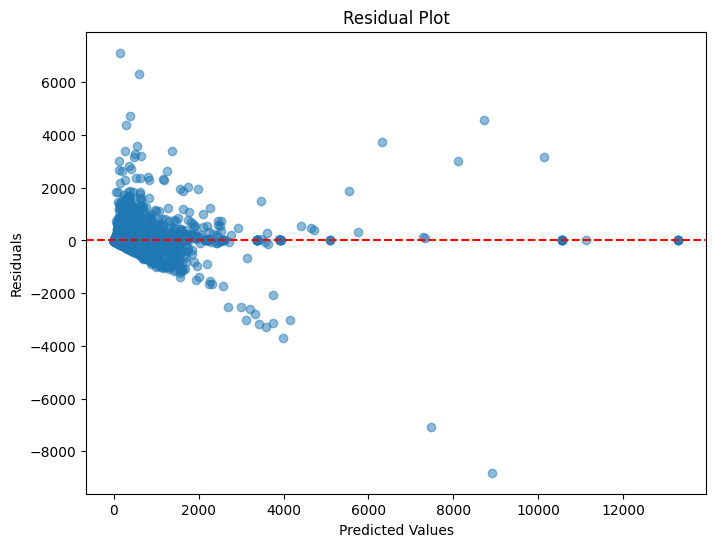

In [17]:
plt.figure(figsize=(8,6))

plt.scatter(predictions, residuals, alpha=0.5)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

In [18]:
'''
### Observation

The residuals are randomly distributed around zero, indicating that the model does not show a strong systematic prediction bias.
'''

'\n### Observation\n\nThe residuals are randomly distributed around zero, indicating that the model does not show a strong systematic prediction bias.\n'

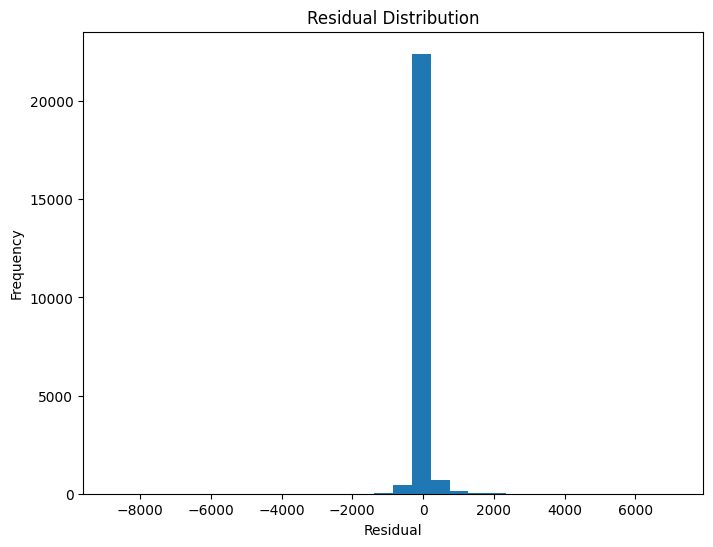

In [19]:
plt.figure(figsize=(8,6))

plt.hist(
    residuals,
    bins=30
)

plt.xlabel("Residual")

plt.ylabel("Frequency")

plt.title("Residual Distribution")

plt.show()

In [20]:
'''
### Observation

The residual distribution is centered close to zero, suggesting that prediction errors are generally balanced with no significant skewness.
'''

'\n### Observation\n\nThe residual distribution is centered close to zero, suggesting that prediction errors are generally balanced with no significant skewness.\n'

In [21]:
feature_importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": model.feature_importances_

})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
7,product_description_lenght,0.211227
13,payment_sequential,0.181954
9,product_weight_g,0.110888
25,approval_days,0.077834
1,customer_zip_code_prefix,0.041163
5,product_category_name,0.040584
10,product_length_cm,0.037329
12,product_width_cm,0.028987
4,order_item_id,0.026400
19,purchase_day,0.023412


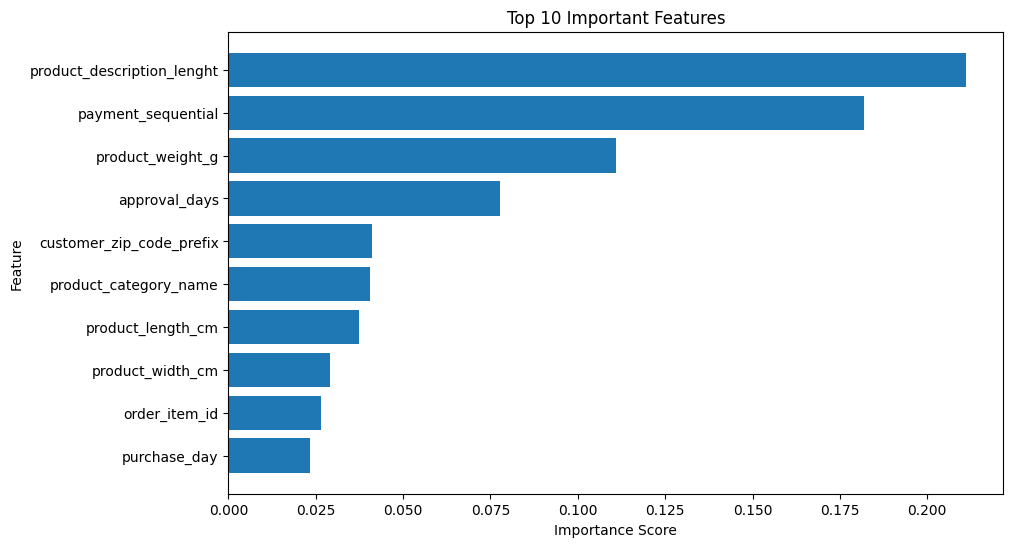

In [22]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance Score")

plt.ylabel("Feature")

plt.title("Top 10 Important Features")

plt.gca().invert_yaxis()

plt.show()

# Business Insights

Based on the model evaluation, the following insights were observed:

- The Random Forest model achieved the highest prediction accuracy among all evaluated models.
- Customer purchasing behavior is influenced by multiple features rather than a simple linear relationship.
- Product characteristics, customer location, payment details, and delivery-related features contribute significantly to predicting order value.
- The model can help estimate future order values and support business decision-making

# Conclusion

A complete machine learning evaluation was performed on the Olist E-commerce dataset.

The Random Forest Regressor achieved the best performance with:

- Mean Absolute Error (MAE): 86.53
- Root Mean Squared Error (RMSE): 222.33
- R² Score: 0.7591

The evaluation demonstrates that the model can effectively predict customer order values and provides valuable insights for pricing analysis, customer behavior analysis, and revenue forecasting.

Future improvements may include hyper
parameter tuning, advanced feature engineering, and testing additional ensemble models such as XGBoost or LightGBM.